In [1]:
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")
from diffPLOG2TROE.rate_constants import Arrhenius
from diffPLOG2TROE.rate_constants.arrhenius import refit_arrhenius
from diffPLOG2TROE.boundaries import Boundaries

57.29710231852266 -3.869999999999989 2952.692611347644
59.59968741151639 -3.8699999999999513 2952.6926113475956
[  57.29710232   -3.87       2952.69261135]
[  59.59968741   -3.87       2952.69261135]


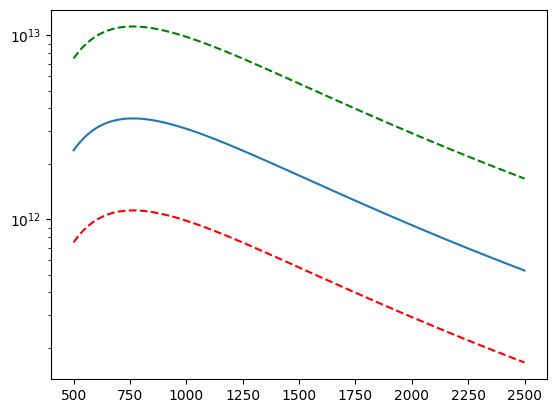

In [2]:
T_range = jnp.linspace(500, 2500, 100)
nominal_rate = Arrhenius({
    "name": "nominal rate",
    "type": "arrhenius",
    "rate-constant": {"coefficients": jnp.array([2.420e+25, -3.870, 5.867e+03])}
})
k_nominal = nominal_rate.kinetic_constant(T_range)
boundaries = Boundaries(k_nominal, 0.5, "simmetric", (500, 2500), 100)
lb_params, ub_params = boundaries.compute_boundaries()

lb_rate = Arrhenius({
    "name": "nominal rate",
    "type": "arrhenius",
    "rate-constant": {"coefficients": jnp.array([jnp.exp(lb_params[0]), lb_params[1], lb_params[2]*1.987])}
})
k_lb = lb_rate.kinetic_constant(T_range)

ub_rate = Arrhenius({
    "name": "nominal rate",
    "type": "arrhenius",
    "rate-constant": {"coefficients": jnp.array([jnp.exp(ub_params[0]), ub_params[1], ub_params[2]*1.987])}
})
k_ub = ub_rate.kinetic_constant(T_range)

plt.semilogy(T_range, k_nominal)
plt.semilogy(T_range, k_lb, "r--")
plt.semilogy(T_range, k_ub, "g--")
plt.show()